<a href="https://colab.research.google.com/github/IMPERIUMSIXTH/JupyterNotebooks/blob/main/Zindi1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import seaborn as sns
import polars as pl
import duckdb as db
import sklearn as sk
import matplotlib.pyplot as plt
import scipy as sp
import pandas as pd

print("All imported")

All imported


In [2]:
from google.colab import files
uploaded=files.upload()

Saving Test.csv to Test.csv
Saving Train.csv to Train.csv


In [3]:
traindf = pl.read_csv('Train.csv')

In [4]:
!pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 80.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.5 MB/s eta 0:00:00


In [5]:
from ydata_profiling import ProfileReport
pd_traindf = traindf.to_pandas()
report = ProfileReport(pd_traindf, title='Training Data Profile')
report.to_notebook_iframe()

/tmp/ipykernel_897/2322261077.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 13/13 [00:00<00:00, 15.52it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [6]:
education_bank_account_pivot = pd.crosstab(pd_traindf['education_level'], pd_traindf['bank_account'])
display(education_bank_account_pivot)

bank_account,No,Yes
education_level,,
No formal education,4339,176
Other/Dont know/RTA,24,11
Primary education,11698,1093
Secondary education,3240,983
Tertiary education,566,591
Vocational/Specialised training,345,458


In [7]:
from scipy.stats import chi2_contingency

# Prepare the contingency table for the Chi-squared test.
# We need the raw counts, so exclude 'Total' and 'Percentage_With_Bank_Account' if they were added.
contingency_table = education_bank_account_pivot[['No', 'Yes']]

# Perform the Chi-squared test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-squared Statistic: {chi2:.2f}")
print(f"P-value: {p_value:.3e}") # Display p-value in scientific notation for very small values
print(f"Degrees of Freedom: {dof}")
print("\nExpected Frequencies Table:")
display(pd.DataFrame(expected, columns=contingency_table.columns, index=contingency_table.index))

Chi-squared Statistic: 3549.13
P-value: 0.000e+00
Degrees of Freedom: 5

Expected Frequencies Table:


bank_account,No,Yes
education_level,,
No formal education,3879.322394,635.677606
Other/Dont know/RTA,30.072267,4.927733
Primary education,10990.124639,1800.875361
Secondary education,3628.433770,594.566230
Tertiary education,994.103214,162.896786
Vocational/Specialised training,689.943717,113.056283


In [8]:
education_bank_account_pivot['Total'] = education_bank_account_pivot['No'] + education_bank_account_pivot['Yes']
education_bank_account_pivot['Percentage_With_Bank_Account'] = (education_bank_account_pivot['Yes'] / education_bank_account_pivot['Total']) * 100
display(education_bank_account_pivot[['Percentage_With_Bank_Account']].sort_values(by='Percentage_With_Bank_Account', ascending=False))

bank_account,Percentage_With_Bank_Account
education_level,
Vocational/Specialised training,57.036115
Tertiary education,51.080380
Other/Dont know/RTA,31.428571
Secondary education,23.277291
Primary education,8.545071
No formal education,3.898117


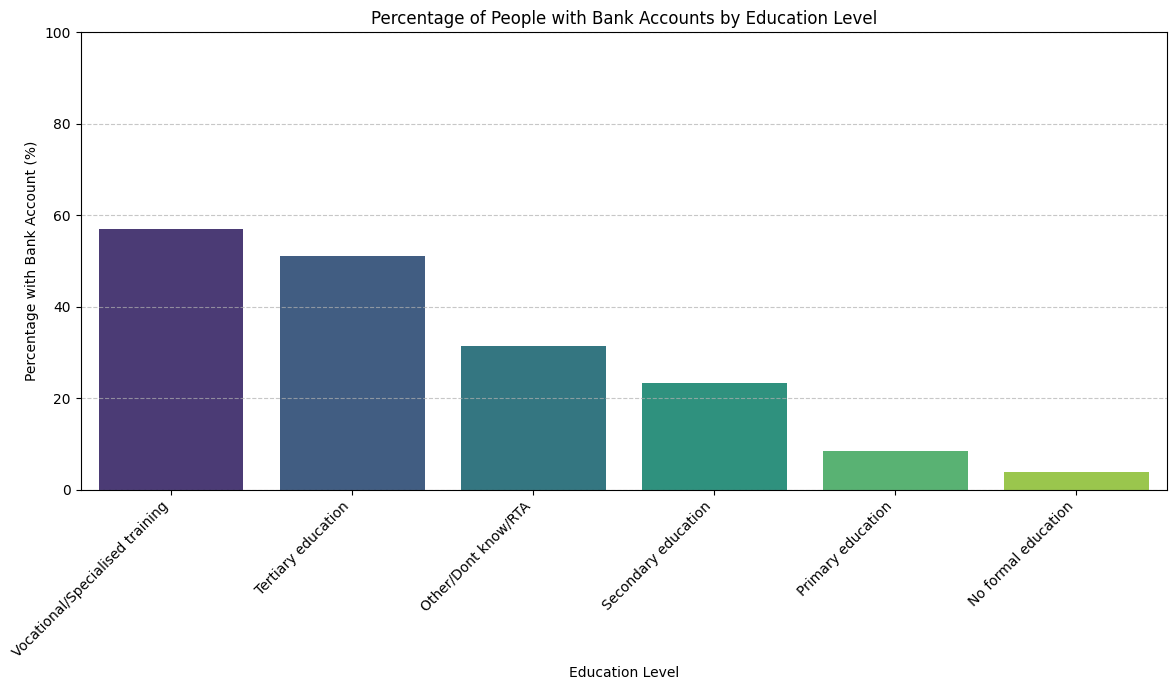

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort the data for better visualization, similar to the previous display
plot_data = education_bank_account_pivot[['Percentage_With_Bank_Account']].sort_values(by='Percentage_With_Bank_Account', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x=plot_data.index, y='Percentage_With_Bank_Account', data=plot_data, palette='viridis', hue=plot_data.index, legend=False)
plt.title('Percentage of People with Bank Accounts by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Percentage with Bank Account (%)')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for readability
plt.ylim(0, 100) # Ensure y-axis goes from 0 to 100%
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

In [10]:
print('Columns available for analysis:')
display(pd_traindf.columns.tolist())

Columns available for analysis:


['country',
 'year',
 'uniqueid',
 'bank_account',
 'location_type',
 'cellphone_access',
 'household_size',
 'age_of_respondent',
 'gender_of_respondent',
 'relationship_with_head',
 'marital_status',
 'education_level',
 'job_type']

### One-Hot Encoding for Categorical Features and Target Variable Conversion

I will now perform one-hot encoding on the identified categorical features using `pd.get_dummies`. This converts categorical variables into a format that can be provided to machine learning algorithms. Each category value is converted into a new column, and assigned a 1 or 0 (True/False) value to the column. I will also convert the `bank_account` column, which is our target variable, into a numerical format (0 for 'No', 1 for 'Yes').

In [11]:
# Identify categorical columns to be one-hot encoded
categorical_cols = [
    'country',
    'location_type',
    'cellphone_access',
    'gender_of_respondent',
    'relationship_with_head',
    'marital_status',
    'education_level',
    'job_type',
    'year' # Treating year as categorical for now for encoding
]

# Apply one-hot encoding
df_encoded = pd.get_dummies(pd_traindf, columns=categorical_cols, drop_first=True) # drop_first avoids multicollinearity

# Convert 'bank_account' target variable to numerical (0/1)
df_encoded['bank_account'] = df_encoded['bank_account'].map({'No': 0, 'Yes': 1})

display(df_encoded.head())

,uniqueid,bank_account,household_size,age_of_respondent,country_Rwanda,country_Tanzania,country_Uganda,location_type_Urban,cellphone_access_Yes,gender_of_respondent_Male,...,job_type_Formally employed Government,job_type_Formally employed Private,job_type_Government Dependent,job_type_Informally employed,job_type_No Income,job_type_Other Income,job_type_Remittance Dependent,job_type_Self employed,year_2017,year_2018
0,uniqueid_1,1,3,24,False,False,False,False,True,False,...,False,False,False,False,False,False,False,True,False,True
1,uniqueid_2,0,5,70,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,True
2,uniqueid_3,1,5,26,False,False,False,True,True,True,...,False,False,False,False,False,False,False,True,False,True
3,uniqueid_4,0,5,34,False,False,False,False,True,False,...,False,True,False,False,False,False,False,False,False,True
4,uniqueid_5,0,8,26,False,False,False,True,False,True,...,False,False,False,True,False,False,False,False,False,True


### Correlation Analysis with Heatmap

Now, let's compute the correlation matrix for `df_encoded` and visualize the correlations as a heatmap. We'll specifically focus on the correlations with our target variable, `bank_account`.

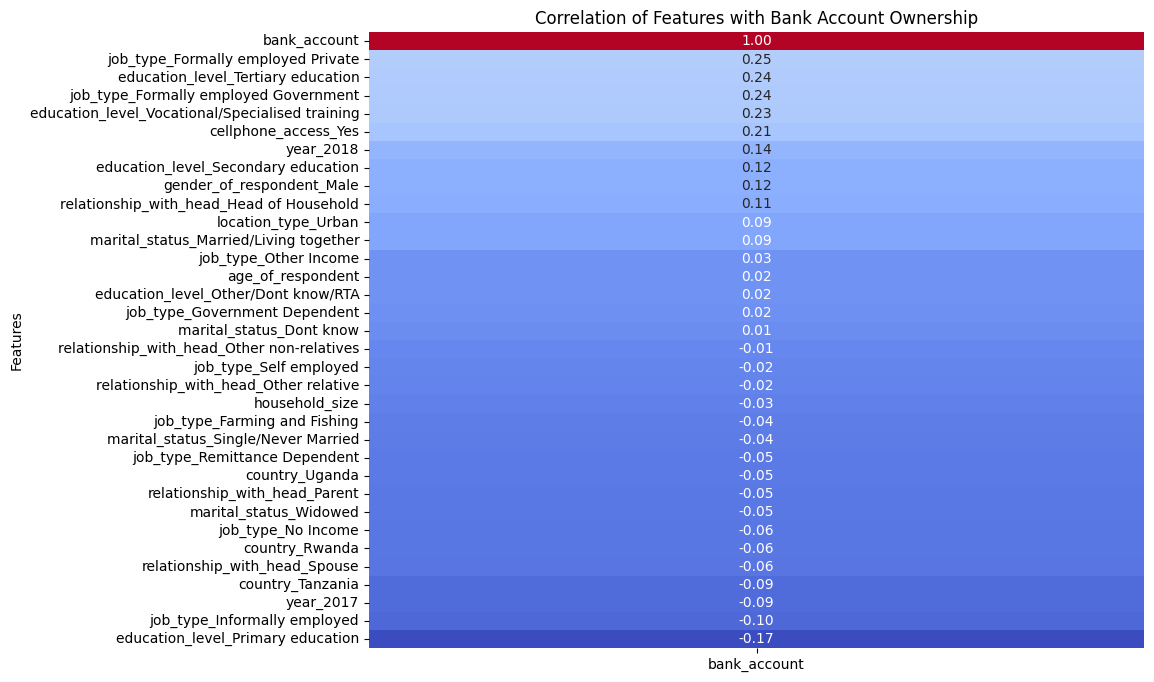

In [12]:
# Calculate the correlation matrix
correlation_matrix = df_encoded.corr(numeric_only=True)

# Sort the correlations with 'bank_account' for better readability
correlation_with_bank_account = correlation_matrix['bank_account'].sort_values(ascending=False)

# Create a heatmap of the correlations with 'bank_account'
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_with_bank_account.to_frame(), annot=True, cmap='coolwarm', fmt=".2f", cbar=False)
plt.title('Correlation of Features with Bank Account Ownership')
plt.ylabel('Features')
plt.show()

### Visualizing the Full Correlation Matrix

To understand how all factors influence each other, let's visualize the complete correlation matrix for `df_encoded`. This heatmap will show the pairwise correlation between every variable in our processed dataset.

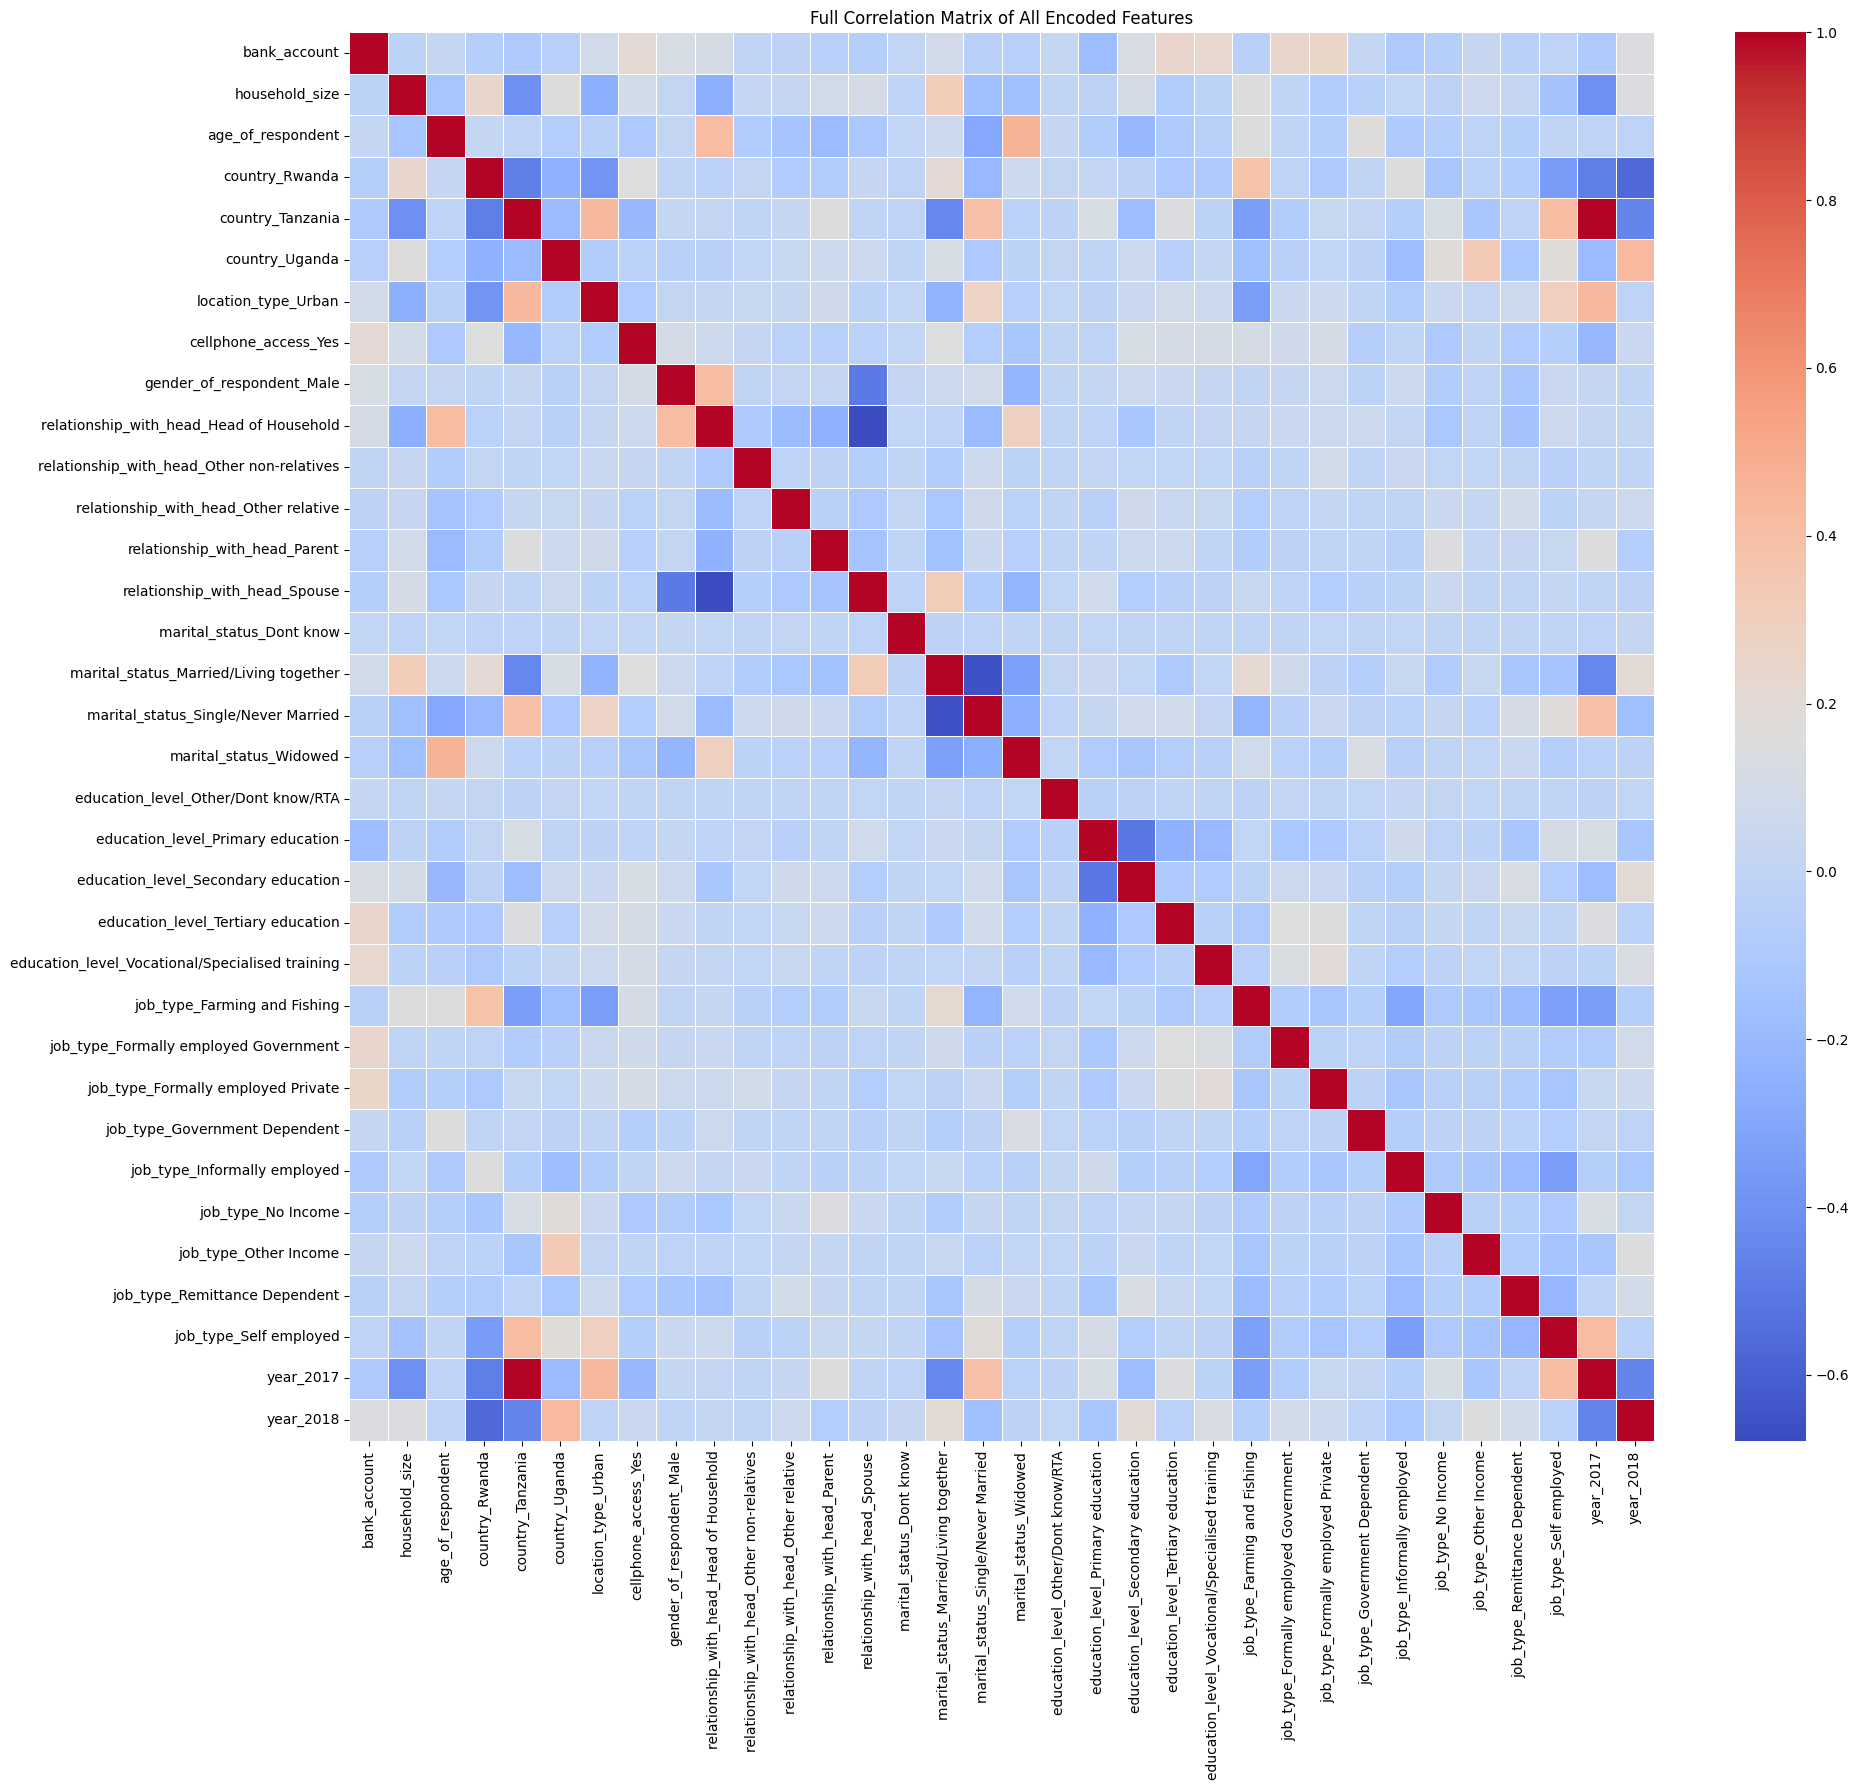

In [13]:
# Calculate the full correlation matrix (already done as 'correlation_matrix')

# Set up the matplotlib figure
plt.figure(figsize=(20, 18)) # Adjust size for readability with many features

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Full Correlation Matrix of All Encoded Features')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Data Splitting for Model Training and Evaluation

We will split our `df_encoded` DataFrame into features (X) and the target variable (y). Then, we'll use `train_test_split` from `sklearn.model_selection` to create training and testing subsets.

In [14]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_encoded.drop(['uniqueid', 'bank_account'], axis=1) # Drop 'uniqueid' and the target variable
y = df_encoded['bank_account']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

# Display the first few rows of the training features
display(X_train.head())

Shape of X_train: (18819, 33)
Shape of X_test: (4705, 33)
Shape of y_train: (18819,)
Shape of y_test: (4705,)


,household_size,age_of_respondent,country_Rwanda,country_Tanzania,country_Uganda,location_type_Urban,cellphone_access_Yes,gender_of_respondent_Male,relationship_with_head_Head of Household,relationship_with_head_Other non-relatives,...,job_type_Formally employed Government,job_type_Formally employed Private,job_type_Government Dependent,job_type_Informally employed,job_type_No Income,job_type_Other Income,job_type_Remittance Dependent,job_type_Self employed,year_2017,year_2018
3535,4,28,False,False,False,False,True,False,False,False,...,False,False,False,True,False,False,False,False,False,True
10836,6,63,True,False,False,False,False,True,True,False,...,False,False,False,False,False,False,False,False,False,False
23078,5,34,False,False,True,False,True,False,True,False,...,False,False,False,False,False,False,False,True,False,True
10569,7,56,True,False,False,False,False,True,True,False,...,False,False,False,True,False,False,False,False,False,False
9135,7,35,True,False,False,False,True,True,True,False,...,False,False,False,False,False,False,False,False,False,False


### Model Selection: Logistic Regression

For this binary classification problem (predicting whether someone has a bank account or not), Logistic Regression is a good starting point. It's a linear model that is simple to interpret and computationally efficient.

First, let's import the `LogisticRegression` model and train it on our `X_train` and `y_train` data.

In [15]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model with class_weight='balanced'
model = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000, class_weight='balanced') # 'liblinear' solver works well for small datasets and handles L1/L2 regularization

# Train the model
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully with balanced class weights!")

Logistic Regression model trained successfully with balanced class weights!


Model Accuracy (with balanced class weights): 0.7919

Classification Report (with balanced class weights):
              precision    recall  f1-score   support

           0       0.95      0.80      0.87      4043
           1       0.38      0.76      0.51       662

    accuracy                           0.79      4705
   macro avg       0.67      0.78      0.69      4705
weighted avg       0.87      0.79      0.82      4705



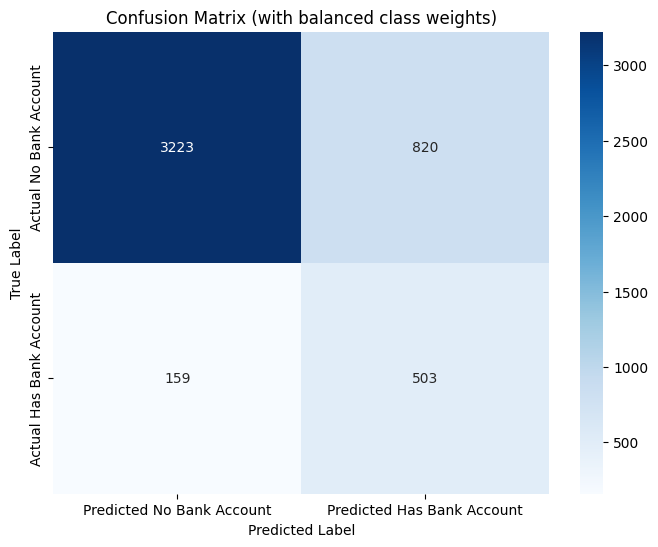

In [16]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions on the test set with the re-trained model
y_pred_balanced = model.predict(X_test)

# Calculate accuracy
accuracy_balanced = accuracy_score(y_test, y_pred_balanced)
print(f"Model Accuracy (with balanced class weights): {accuracy_balanced:.4f}\n")

# Display classification report
print("Classification Report (with balanced class weights):")
print(classification_report(y_test, y_pred_balanced))

# Display confusion matrix
cm_balanced = confusion_matrix(y_test, y_pred_balanced)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_balanced, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Bank Account', 'Predicted Has Bank Account'],
            yticklabels=['Actual No Bank Account', 'Actual Has Bank Account'])
plt.title('Confusion Matrix (with balanced class weights)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Model Selection: Random Forest Classifier

Let's try a more powerful model, a Random Forest Classifier, which is an ensemble learning method that can often provide higher accuracy and better handle class imbalance, even without explicit class weighting, due to its tree-based nature. We will train it and then evaluate its performance.

In [17]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier
# We can also use class_weight='balanced' here if needed, but often RF handles imbalance better inherently.
rf_model = RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced')

# Train the Random Forest model
rf_model.fit(X_train, y_train)

print("Random Forest Classifier trained successfully!")

Random Forest Classifier trained successfully!


### Random Forest Model Evaluation

Now, let's evaluate the performance of our Random Forest Classifier on the test set and compare its metrics to the Logistic Regression model.

Random Forest Model Accuracy: 0.8567

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.93      0.92      4043
           1       0.49      0.43      0.46       662

    accuracy                           0.86      4705
   macro avg       0.70      0.68      0.69      4705
weighted avg       0.85      0.86      0.85      4705



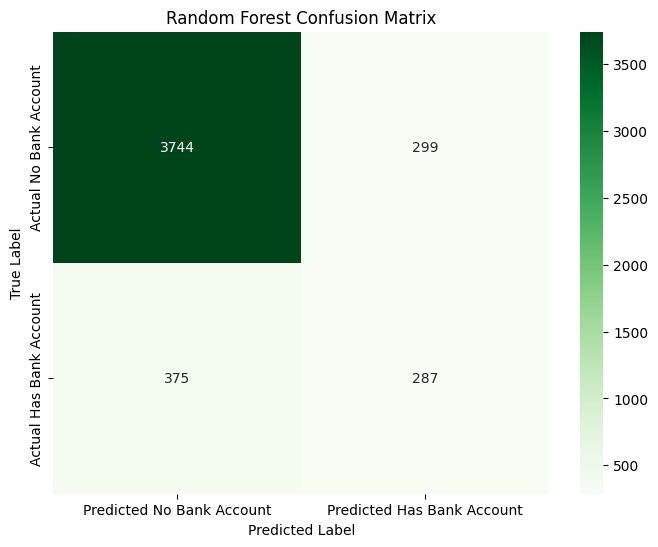

In [18]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions on the test set with the Random Forest model
y_pred_rf = rf_model.predict(X_test)

# Calculate accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Model Accuracy: {accuracy_rf:.4f}\n")

# Display classification report
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

# Display confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted No Bank Account', 'Predicted Has Bank Account'],
            yticklabels=['Actual No Bank Account', 'Actual Has Bank Account'])
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Model Selection: XGBoost Classifier

Given the performance of previous models and the desire for better predictive power, let's try an XGBoost Classifier. XGBoost (Extreme Gradient Boosting) is an optimized distributed gradient boosting library designed to be highly efficient, flexible, and portable. It often provides state-of-the-art results on many tabular datasets.

We will also incorporate `scale_pos_weight` to handle the class imbalance, similar to how `class_weight='balanced'` was used in Logistic Regression and Random Forest.

In [19]:
# Install XGBoost if not already installed
!pip install xgboost

In [20]:
from xgboost import XGBClassifier

# Calculate scale_pos_weight for class imbalance
# This is equivalent to class_weight='balanced' for binary classification in other models
neg_count = y_train.value_counts()[0]
pos_count = y_train.value_counts()[1]
scale_pos_weight_value = neg_count / pos_count

print(f"Scale Pos Weight: {scale_pos_weight_value:.2f}")

# Initialize the XGBoost Classifier
# Using a small learning rate and more estimators for better generalization
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False, # Suppress warning
    random_state=42,
    n_estimators=300, # Increased number of estimators
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight_value # Handle class imbalance
)

# Train the XGBoost model
xgb_model.fit(X_train, y_train)

print("XGBoost Classifier trained successfully!")

Scale Pos Weight: 6.10


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:59:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Classifier trained successfully!


### XGBoost Model Evaluation

Now, let's evaluate the performance of our XGBoost Classifier on the test set and compare its metrics to the previous models.

XGBoost Model Accuracy: 0.8104

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.82      0.88      4043
           1       0.40      0.72      0.52       662

    accuracy                           0.81      4705
   macro avg       0.68      0.77      0.70      4705
weighted avg       0.87      0.81      0.83      4705



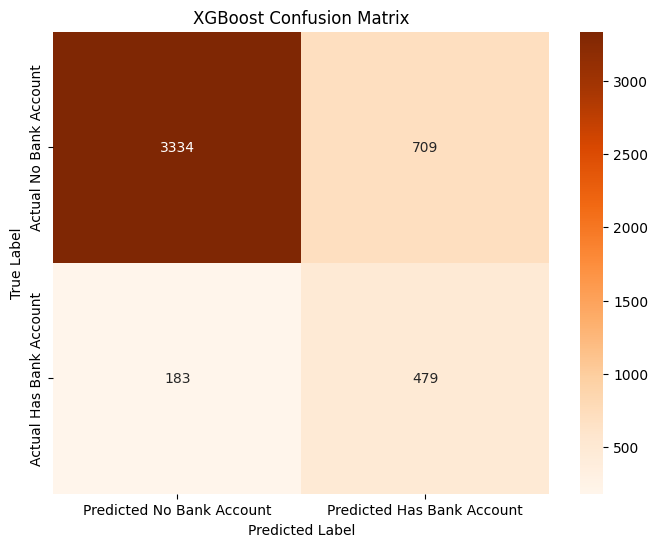

In [21]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set with the XGBoost model
y_pred_xgb = xgb_model.predict(X_test)

# Calculate accuracy
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Model Accuracy: {accuracy_xgb:.4f}\n")

# Display classification report
print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))

# Display confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Predicted No Bank Account', 'Predicted Has Bank Account'],
            yticklabels=['Actual No Bank Account', 'Actual Has Bank Account'])
plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Random Forest Feature Importance

One of the great advantages of tree-based models like Random Forests is their ability to provide feature importances. This helps us understand which features contribute most to the model's predictions. Let's extract and visualize these importances.

,Feature,Importance
1,age_of_respondent,0.304187
0,household_size,0.131824
6,cellphone_access_Yes,0.088638
5,location_type_Urban,0.045916
20,education_level_Tertiary education,0.040362
18,education_level_Primary education,0.034307
24,job_type_Formally employed Private,0.031720
21,education_level_Vocational/Specialised training,0.029843
19,education_level_Secondary education,0.029783
7,gender_of_respondent_Male,0.026931


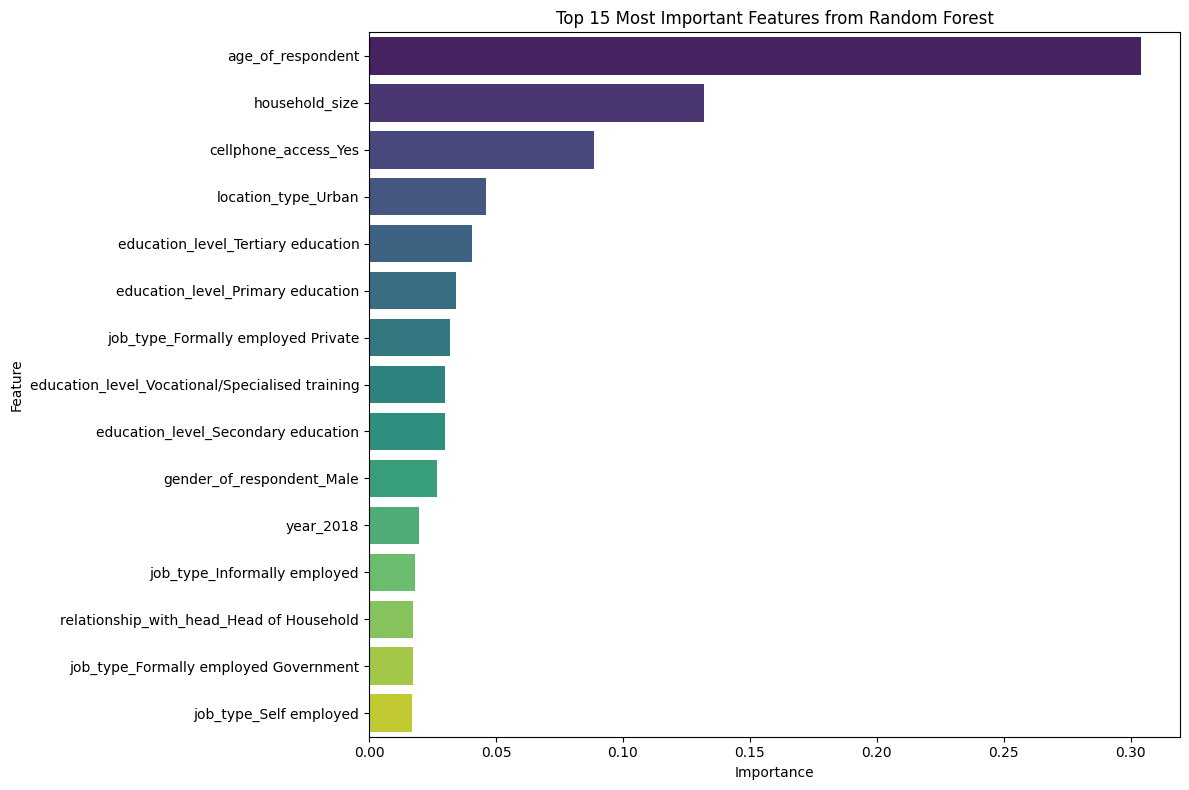

In [22]:
# Get feature importances from the trained Random Forest model
feature_importances = rf_model.feature_importances_

# Create a pandas Series for better visualization
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})

# Sort features by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Display the top N most important features
display(importance_df.head(15))

# Visualize feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15), palette='viridis', hue='Feature', legend=False) # Fixed FutureWarning
plt.title('Top 15 Most Important Features from Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Hyperparameter Tuning for Random Forest

To improve the recall of the Random Forest model, we will perform hyperparameter tuning using `RandomizedSearchCV`. This method allows us to efficiently search a defined range of hyperparameter values to find the combination that yields the best performance, specifically targeting higher recall for the 'Has Bank Account' class.

### Interpreting Random Forest Feature Importance

Based on the feature importances derived from the Random Forest model, we can identify the most significant factors influencing bank account ownership:

1.  **`age_of_respondent`**: This is by far the most important feature, indicating that the age of an individual plays a crucial role in determining whether they have a bank account.
2.  **`household_size`**: The size of the household is the second most influential factor, suggesting that household dynamics are strongly linked to bank account ownership.
3.  **`cellphone_access_Yes`**: Whether an individual has cellphone access is also a very important predictor. This makes intuitive sense as mobile banking and financial services are increasingly prevalent.
4.  **`job_type_Formally employed Private`**: Being formally employed in the private sector is a significant indicator, highlighting the financial stability and regular income associated with bank account usage.
5.  **`year` and `country`**: The `year` and specific `country` indicators also show considerable importance, suggesting that macroeconomic and regional factors influence bank account penetration.

Conversely, some features, particularly certain `marital_status` and `education_level` categories with very low importance, appear to have minimal direct impact on the model's predictions when other features are considered.

These insights can be valuable for targeted interventions or policies aimed at increasing financial inclusion.

In [23]:
from sklearn.model_selection import RandomizedSearchCV

# Define the parameter grid to search
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500], # Number of trees in the forest
    'max_features': ['sqrt', 'log2', None], # Number of features to consider at every split
    'max_depth': [10, 20, 30, 40, 50, None], # Maximum number of levels in tree
    'min_samples_split': [2, 5, 10, 15], # Minimum number of samples required to split a node
    'min_samples_leaf': [1, 2, 4, 6], # Minimum number of samples required at each leaf node
    'class_weight': ['balanced'] # Keep balanced for class imbalance
}

# Initialize RandomizedSearchCV
# n_iter controls the number of parameter settings that are sampled
# scoring='recall' to optimize for recall for the positive class
rf_random = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=50, # Number of random combinations to try
    cv=3, # 3-fold cross-validation
    verbose=2,
    random_state=42,
    n_jobs=-1, # Use all available cores
    scoring='recall' # Optimize for recall
)

# Fit the random search model
rf_random.fit(X_train, y_train)

print("RandomizedSearchCV completed.")
print(f"Best parameters found: {rf_random.best_params_}")
print(f"Best recall score (cross-validated): {rf_random.best_score_:.4f}")

Fitting 3 folds for each of 50 candidates, totalling 150 fits
RandomizedSearchCV completed.
Best parameters found: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 6, 'max_features': 'log2', 'max_depth': 10, 'class_weight': 'balanced'}
Best recall score (cross-validated): 0.7177


### Evaluate Tuned Random Forest Model

Now, let's train a new Random Forest model using the best hyperparameters found by `RandomizedSearchCV` and evaluate its performance on the test set.

Tuned Random Forest Model Accuracy: 0.8034

Tuned Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.81      0.88      4043
           1       0.40      0.77      0.52       662

    accuracy                           0.80      4705
   macro avg       0.68      0.79      0.70      4705
weighted avg       0.88      0.80      0.83      4705



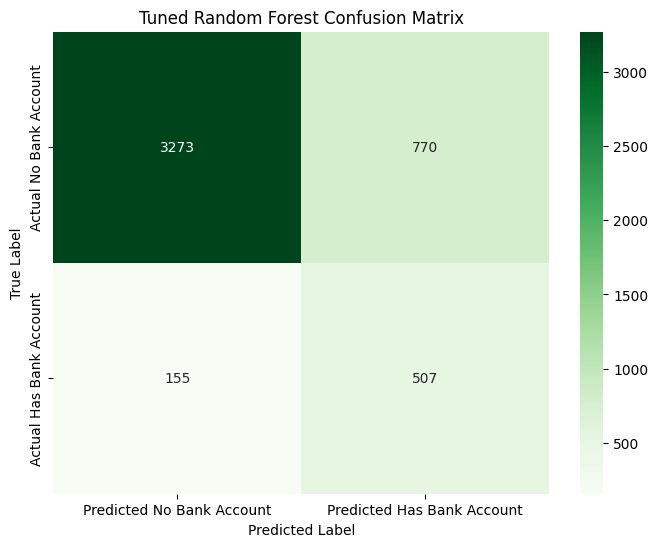

In [24]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Get the best estimator from the random search
rf_best_model = rf_random.best_estimator_

# Make predictions on the test set with the tuned Random Forest model
y_pred_rf_tuned = rf_best_model.predict(X_test)

# Calculate accuracy
accuracy_rf_tuned = accuracy_score(y_test, y_pred_rf_tuned)
print(f"Tuned Random Forest Model Accuracy: {accuracy_rf_tuned:.4f}\n")

# Display classification report
print("Tuned Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf_tuned))

# Display confusion matrix
cm_rf_tuned = confusion_matrix(y_test, y_pred_rf_tuned)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf_tuned, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted No Bank Account', 'Predicted Has Bank Account'],
            yticklabels=['Actual No Bank Account', 'Actual Has Bank Account'])
plt.title('Tuned Random Forest Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Testing Tuned Random Forest Model on `Test.csv`

Now, let's load the `Test.csv` file, preprocess it in the same way as our training data, and then use the `rf_best_model` to predict bank account ownership for this unseen data.

### Impact of Education Level and Job Type on Bank Account Ownership

To understand the specific impact of `education_level` and `job_type`, we can examine their feature importances from the Random Forest model. These values indicate how much each category within these features contributes to the model's prediction of bank account ownership.

In [25]:
# Filter importance_df for education_level and job_type features
education_job_importance = importance_df[importance_df['Feature'].str.contains('education_level|job_type')]

display(education_job_importance)

,Feature,Importance
20,education_level_Tertiary education,0.040362
18,education_level_Primary education,0.034307
24,job_type_Formally employed Private,0.031720
21,education_level_Vocational/Specialised training,0.029843
19,education_level_Secondary education,0.029783
26,job_type_Informally employed,0.017941
23,job_type_Formally employed Government,0.017254
30,job_type_Self employed,0.017103
22,job_type_Farming and Fishing,0.012226
29,job_type_Remittance Dependent,0.011091


#### Observations:

*   **Job Type**: Features related to `job_type`, especially `Formally employed Private` and `Formally employed Government`, show significant importance. This suggests that stable, formal employment is a strong predictor of bank account ownership.
*   **Education Level**: Categories within `education_level`, such as `Tertiary education` and `Vocational/Specialised training`, also exhibit considerable importance. Higher levels of education are often associated with better job opportunities and financial literacy, leading to increased likelihood of owning a bank account.
*   **Relative Importance**: While both are important, formal `job_type` categories appear to have a slightly higher individual impact than specific `education_level` categories. However, it's important to remember that these factors are often correlated in real life.

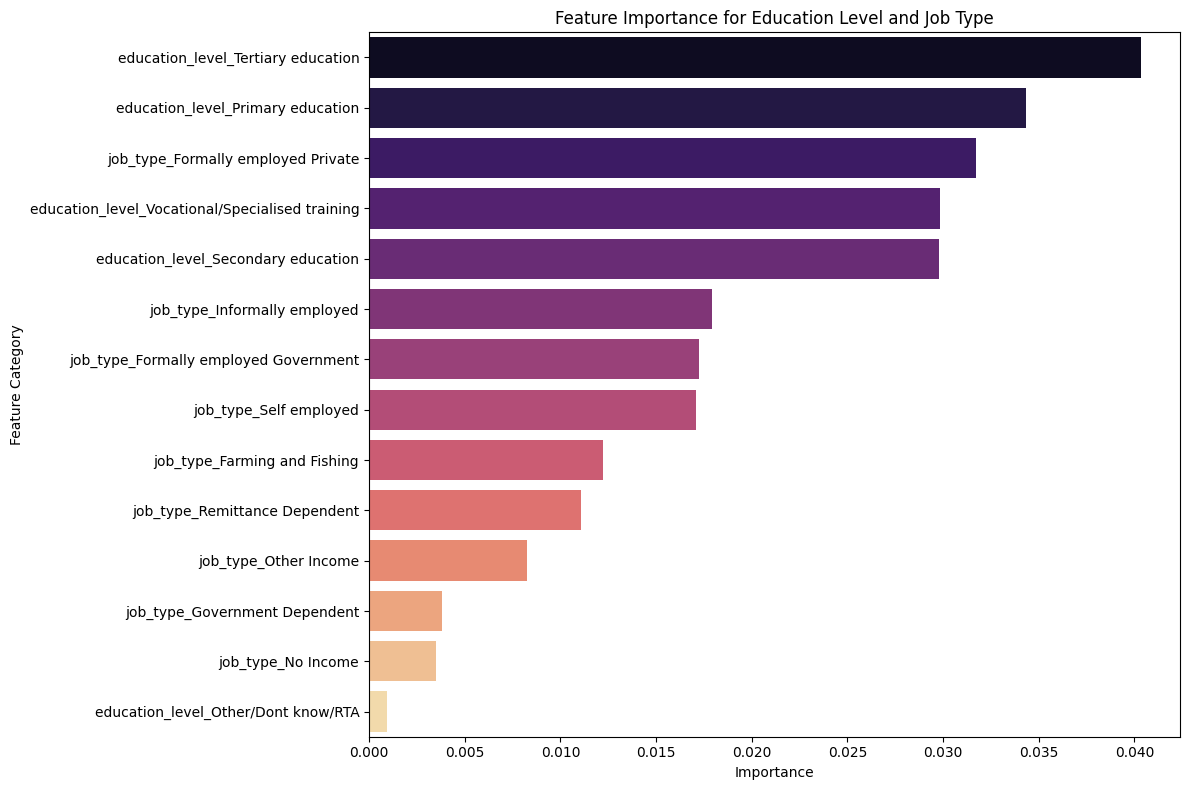

In [26]:
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=education_job_importance.sort_values(by='Importance', ascending=False), palette='magma', hue='Feature', legend=False)
plt.title('Feature Importance for Education Level and Job Type')
plt.xlabel('Importance')
plt.ylabel('Feature Category')
plt.tight_layout()
plt.show()

### Bank Account Ownership Across Age Groups

To analyze the impact of age on bank account ownership, we will categorize respondents into age groups, calculate the percentage of bank account holders within each group, and visualize the findings.

In [27]:
# Define age bins and labels
age_bins = [0, 18, 25, 35, 45, 55, 65, 100]
age_labels = ['<18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']

# Create a new 'age_group' column
pd_traindf['age_group'] = pd.cut(pd_traindf['age_of_respondent'], bins=age_bins, labels=age_labels, right=False)

# Calculate the percentage of bank account holders per age group
age_group_ownership = pd_traindf.groupby('age_group')['bank_account'].value_counts(normalize=True).unstack()

# Calculate the percentage of 'Yes' for each age group, handling cases where a category might not exist
age_group_ownership['Percentage_With_Bank_Account'] = age_group_ownership.get('Yes', 0) * 100

# Display the results
display(age_group_ownership[['Percentage_With_Bank_Account']].sort_index())

/tmp/ipykernel_897/2215677450.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_ownership = pd_traindf.groupby('age_group')['bank_account'].value_counts(normalize=True).unstack()


bank_account,Percentage_With_Bank_Account
age_group,
<18,1.597444
18-24,8.888889
25-34,16.633481
35-44,17.937883
45-54,15.583174
55-64,13.715953
65+,10.958296


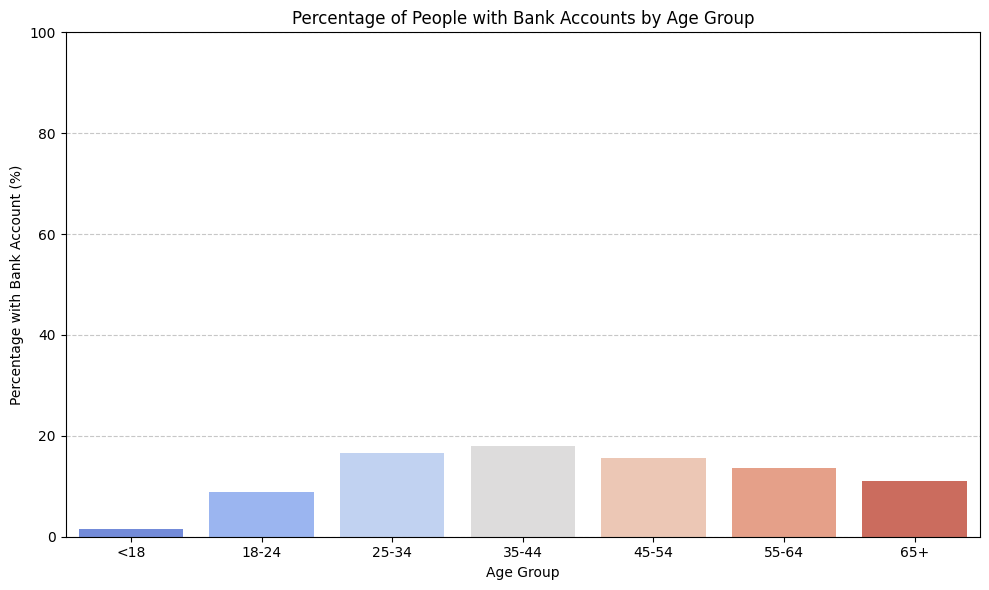

In [28]:
plt.figure(figsize=(10, 6))
sns.barplot(x=age_group_ownership.index, y='Percentage_With_Bank_Account', data=age_group_ownership, palette='coolwarm', hue=age_group_ownership.index, legend=False)
plt.title('Percentage of People with Bank Accounts by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Percentage with Bank Account (%)')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [29]:
test_df = pl.read_csv('Test.csv')
pd_test_df = test_df.to_pandas()

# Display the first few rows of the raw test data
print("Raw Test Data Head:")
display(pd_test_df.head())

Raw Test Data Head:


,country,year,uniqueid,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,uniqueid_6056,Urban,Yes,3,30,Male,Head of Household,Married/Living together,Secondary education,Formally employed Government
1,Kenya,2018,uniqueid_6060,Urban,Yes,7,51,Male,Head of Household,Married/Living together,Vocational/Specialised training,Formally employed Private
2,Kenya,2018,uniqueid_6065,Rural,No,3,77,Female,Parent,Married/Living together,No formal education,Remittance Dependent
3,Kenya,2018,uniqueid_6072,Rural,No,6,39,Female,Head of Household,Married/Living together,Primary education,Remittance Dependent
4,Kenya,2018,uniqueid_6073,Urban,No,3,16,Male,Child,Single/Never Married,Secondary education,Remittance Dependent


In [30]:
# Identify categorical columns to be one-hot encoded (same as for training data)
categorical_cols_test = [
    'country',
    'location_type',
    'cellphone_access',
    'gender_of_respondent',
    'relationship_with_head',
    'marital_status',
    'education_level',
    'job_type',
    'year'
]

# Apply one-hot encoding to the test data
df_test_encoded = pd.get_dummies(pd_test_df, columns=categorical_cols_test, drop_first=True)

# Ensure the columns in the test set match the training set features (X_train)
# Add missing columns with 0 and remove extra columns
missing_cols = set(X_train.columns) - set(df_test_encoded.columns)
for c in missing_cols:
    df_test_encoded[c] = 0

extra_cols = set(df_test_encoded.columns) - set(X_train.columns)
df_test_encoded = df_test_encoded.drop(columns=list(extra_cols))

# Align columns in the same order as X_train
df_test_encoded = df_test_encoded[X_train.columns]

# Drop 'uniqueid' if it exists in the test features (should not be used for prediction)
if 'uniqueid' in df_test_encoded.columns:
    X_test_prod = df_test_encoded.drop('uniqueid', axis=1)
else:
    X_test_prod = df_test_encoded

print("Processed Test Data Head:")
display(X_test_prod.head())
print(f"Shape of processed test data (X_test_prod): {X_test_prod.shape}")

Processed Test Data Head:


,household_size,age_of_respondent,country_Rwanda,country_Tanzania,country_Uganda,location_type_Urban,cellphone_access_Yes,gender_of_respondent_Male,relationship_with_head_Head of Household,relationship_with_head_Other non-relatives,...,job_type_Formally employed Government,job_type_Formally employed Private,job_type_Government Dependent,job_type_Informally employed,job_type_No Income,job_type_Other Income,job_type_Remittance Dependent,job_type_Self employed,year_2017,year_2018
0,3,30,False,False,False,True,True,True,True,False,...,True,False,False,False,False,False,False,False,False,True
1,7,51,False,False,False,True,True,True,True,False,...,False,True,False,False,False,False,False,False,False,True
2,3,77,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
3,6,39,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
4,3,16,False,False,False,True,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True


Shape of processed test data (X_test_prod): (10086, 33)


In [31]:
# Make predictions on the preprocessed test data using the tuned Random Forest model
predictions_rf_tuned_test = rf_best_model.predict(X_test_prod)

# Create a DataFrame for the predictions with uniqueid for submission or identification
submission_df = pd.DataFrame({'uniqueid': pd_test_df['uniqueid'], 'bank_account_predicted': predictions_rf_tuned_test})

# Convert numerical predictions back to 'Yes'/'No' for readability
submission_df['bank_account_predicted'] = submission_df['bank_account_predicted'].map({0: 'No', 1: 'Yes'})

print("Predictions on Test.csv using Tuned Random Forest Model:")
display(submission_df.head())

Predictions on Test.csv using Tuned Random Forest Model:


,uniqueid,bank_account_predicted
0,uniqueid_6056,Yes
1,uniqueid_6060,Yes
2,uniqueid_6065,No
3,uniqueid_6072,No
4,uniqueid_6073,No


In [32]:
# Save the submission DataFrame to a CSV file
submission_df.to_csv('bank_account_predictions.csv', index=False)

print("Predictions saved to bank_account_predictions.csv")

Predictions saved to bank_account_predictions.csv


### Model Evaluation

Now that our model is trained, let's evaluate its performance on the test set (`X_test`, `y_test`). We'll use common classification metrics such as accuracy, precision, recall, F1-score, and a confusion matrix to understand how well the model predicts bank account ownership.

Model Accuracy: 0.7919

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.80      0.87      4043
           1       0.38      0.76      0.51       662

    accuracy                           0.79      4705
   macro avg       0.67      0.78      0.69      4705
weighted avg       0.87      0.79      0.82      4705



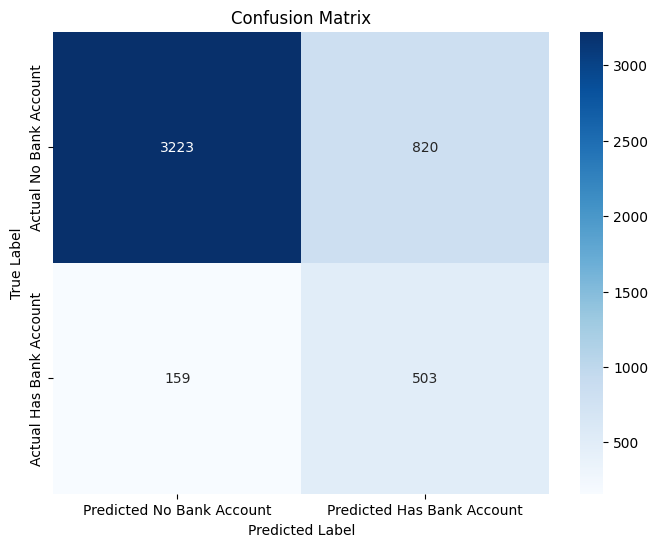

In [33]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}\n")

# Display classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Display confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Bank Account', 'Predicted Has Bank Account'],
            yticklabels=['Actual No Bank Account', 'Actual Has Bank Account'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [36]:
from google.colab import files
uploaded=files.upload()

Saving SampleSubmission.csv to SampleSubmission.csv
Saving submission.csv to submission (1).csv


### Final Submission File

### Verify Submission File Format

In [39]:
sample_submission_df = pd.read_csv('/content/SampleSubmission.csv')
final_submission_df = pd.read_csv('bank_account_predictions.csv')

print("\nSample Submission File Head:")
display(sample_submission_df.head())
print("Sample Submission File Columns:")
display(sample_submission_df.columns.tolist())

print("\nGenerated Submission File Head:")
display(final_submission_df.head())
print("Generated Submission File Columns:")
display(final_submission_df.columns.tolist())

# Compare columns
if list(sample_submission_df.columns) == list(final_submission_df.columns):
    print("\nColumn names match the sample submission file.")
else:
    print("\nColumn names DO NOT match the sample submission file. Please check the expected format.")


Sample Submission File Head:


,unique_id,bank_account
0,uniqueid_1 x Kenya,0
1,uniqueid_2 x Kenya,0
2,uniqueid_3 x Kenya,0
3,uniqueid_4 x Kenya,0
4,uniqueid_5 x Kenya,0


Sample Submission File Columns:


['unique_id', 'bank_account']


Generated Submission File Head:


,uniqueid,bank_account_predicted
0,uniqueid_6056,Yes
1,uniqueid_6060,Yes
2,uniqueid_6065,No
3,uniqueid_6072,No
4,uniqueid_6073,No


Generated Submission File Columns:


['uniqueid', 'bank_account_predicted']


Column names DO NOT match the sample submission file. Please check the expected format.


In [40]:
# Rename columns in final_submission_df to match SampleSubmission.csv
final_submission_df.rename(columns={
    'uniqueid': 'unique_id',
    'bank_account_predicted': 'bank_account'
}, inplace=True)

print("\n--- After Renaming Columns ---")
print("Sample Submission File Head:")
display(sample_submission_df.head())
print("Sample Submission File Columns:")
display(sample_submission_df.columns.tolist())

print("\nGenerated Submission File Head (Corrected):")
display(final_submission_df.head())
print("Generated Submission File Columns (Corrected):")
display(final_submission_df.columns.tolist())

# Re-compare columns after renaming
if list(sample_submission_df.columns) == list(final_submission_df.columns):
    print("\nSUCCESS: Column names now match the sample submission file.")
else:
    print("\nERROR: Column names still DO NOT match. Please investigate.")

# Save the corrected submission DataFrame to a CSV file
final_submission_df.to_csv('bank_account_predictions.csv', index=False)
print("\nCorrected predictions saved to bank_account_predictions.csv. You can download it from the 'Files' section.")


--- After Renaming Columns ---
Sample Submission File Head:


,unique_id,bank_account
0,uniqueid_1 x Kenya,0
1,uniqueid_2 x Kenya,0
2,uniqueid_3 x Kenya,0
3,uniqueid_4 x Kenya,0
4,uniqueid_5 x Kenya,0


Sample Submission File Columns:


['unique_id', 'bank_account']


Generated Submission File Head (Corrected):


,unique_id,bank_account
0,uniqueid_6056,Yes
1,uniqueid_6060,Yes
2,uniqueid_6065,No
3,uniqueid_6072,No
4,uniqueid_6073,No


Generated Submission File Columns (Corrected):


['unique_id', 'bank_account']


SUCCESS: Column names now match the sample submission file.

Corrected predictions saved to bank_account_predictions.csv. You can download it from the 'Files' section.


In [41]:
# Load the generated submission file to display its head
final_submission_df = pd.read_csv('bank_account_predictions.csv')
display(final_submission_df.head())

print("Your submission file 'bank_account_predictions.csv' is ready. You can download it from the 'Files' section in the left sidebar.")

,unique_id,bank_account
0,uniqueid_6056,Yes
1,uniqueid_6060,Yes
2,uniqueid_6065,No
3,uniqueid_6072,No
4,uniqueid_6073,No


Your submission file 'bank_account_predictions.csv' is ready. You can download it from the 'Files' section in the left sidebar.


In [42]:
uploaded_submission_df = pd.read_csv('/content/submission.csv')

print("\n--- Comparison of SampleSubmission.csv and uploaded submission.csv ---")

print("\nSampleSubmission.csv Head:")
display(sample_submission_df.head())
print("SampleSubmission.csv Columns:")
display(sample_submission_df.columns.tolist())

print("\nUploaded submission.csv Head:")
display(uploaded_submission_df.head())
print("Uploaded submission.csv Columns:")
display(uploaded_submission_df.columns.tolist())

# Compare columns
if list(sample_submission_df.columns) == list(uploaded_submission_df.columns):
    print("\nColumn names in uploaded submission.csv match SampleSubmission.csv.")
else:
    print("\nColumn names in uploaded submission.csv DO NOT match SampleSubmission.csv. Please check the format.")


--- Comparison of SampleSubmission.csv and uploaded submission.csv ---

SampleSubmission.csv Head:


,unique_id,bank_account
0,uniqueid_1 x Kenya,0
1,uniqueid_2 x Kenya,0
2,uniqueid_3 x Kenya,0
3,uniqueid_4 x Kenya,0
4,uniqueid_5 x Kenya,0


SampleSubmission.csv Columns:


['unique_id', 'bank_account']


Uploaded submission.csv Head:


,uniqueid,bank_account
0,uniqueid_6056,1
1,uniqueid_6060,1
2,uniqueid_6065,0
3,uniqueid_6072,0
4,uniqueid_6073,0


Uploaded submission.csv Columns:


['uniqueid', 'bank_account']


Column names in uploaded submission.csv DO NOT match SampleSubmission.csv. Please check the format.


In [44]:
# Rename columns in uploaded_submission_df to match SampleSubmission.csv
uploaded_submission_df.rename(columns={
    'uniqueid': 'unique_id'
}, inplace=True)

# Adjust the 'bank_account' column to be integer type if it's not already (0 or 1)
# This assumes the values are already 0 or 1, and not 'Yes'/'No' strings
uploaded_submission_df['bank_account'] = uploaded_submission_df['bank_account'].astype(int)

# To adjust the unique_id format to 'uniqueid_ID x Country',
# we need to merge with the original test_df to get the 'country' information.
# First, ensure 'unique_id' in uploaded_submission_df matches 'uniqueid' in pd_test_df for merging.

# Create a temporary DataFrame with uniqueid and country from pd_test_df
country_info_df = pd_test_df[['uniqueid', 'country']].copy()
country_info_df.rename(columns={'uniqueid': 'unique_id'}, inplace=True)

# Merge uploaded_submission_df with country_info_df to get the country for each unique_id
uploaded_submission_df = pd.merge(
    uploaded_submission_df,
    country_info_df,
    on='unique_id',
    how='left'
)

# Create the new formatted 'unique_id' column
uploaded_submission_df['unique_id'] = uploaded_submission_df['unique_id'] + ' x ' + uploaded_submission_df['country']

# Drop the temporary 'country' column
uploaded_submission_df.drop(columns=['country'], inplace=True)

# Ensure the columns are in the correct order: ['unique_id', 'bank_account']
uploaded_submission_df = uploaded_submission_df[['unique_id', 'bank_account']]

print("\n--- After Renaming Columns and Formatting Unique ID in uploaded submission.csv ---")
print("SampleSubmission.csv Head:")
display(sample_submission_df.head())
print("SampleSubmission.csv Columns:")
display(sample_submission_df.columns.tolist())

print("\nUploaded submission.csv Head (Corrected):")
display(uploaded_submission_df.head())
print("Uploaded submission.csv Columns (Corrected):")
display(uploaded_submission_df.columns.tolist())

# Re-compare columns after renaming and formatting
if list(sample_submission_df.columns) == list(uploaded_submission_df.columns) and \
   all(sample_submission_df.dtypes == uploaded_submission_df.dtypes):
    print("\nSUCCESS: Column names and data types now match the sample submission file.")
else:
    print("\nERROR: Column names or data types still DO NOT match. Please investigate.")

# Optionally, you can also compare the number of rows
if len(sample_submission_df) == len(uploaded_submission_df):
    print("SUCCESS: Number of rows match the sample submission file.")
else:
    print("WARNING: Number of rows DO NOT match the sample submission file. Sample has", len(sample_submission_df), "rows, generated has", len(uploaded_submission_df), "rows.")


--- After Renaming Columns and Formatting Unique ID in uploaded submission.csv ---
SampleSubmission.csv Head:


,unique_id,bank_account
0,uniqueid_1 x Kenya,0
1,uniqueid_2 x Kenya,0
2,uniqueid_3 x Kenya,0
3,uniqueid_4 x Kenya,0
4,uniqueid_5 x Kenya,0


SampleSubmission.csv Columns:


['unique_id', 'bank_account']


Uploaded submission.csv Head (Corrected):


,unique_id,bank_account
0,uniqueid_6056 x Kenya,1
1,uniqueid_6060 x Kenya,1
2,uniqueid_6065 x Kenya,0
3,uniqueid_6072 x Kenya,0
4,uniqueid_6073 x Kenya,0


Uploaded submission.csv Columns (Corrected):


['unique_id', 'bank_account']


SUCCESS: Column names and data types now match the sample submission file.
